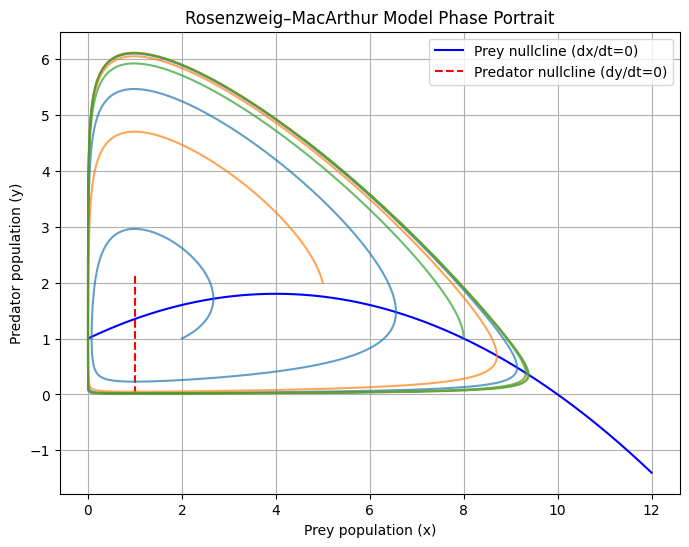

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Rosenzweig-MacArthur parameters
r = 1.0       # prey growth rate
K = 10.0      # prey carrying capacity
a = 1.0       # attack rate
h = 0.5       # handling time
b = 0.75      # conversion efficiency
d = 0.5       # predator death rate

# Prey nullcline (y as a function of x)
x_vals = np.linspace(0.01, K*1.2, 500)
y_prey_nullcline = r*(1 - x_vals/K)*(1 + h*a*x_vals)/a

# Predator nullcline (vertical line)
x_pred_nullcline = d / (b*a - d*h*a)  # x* from nullcline
y_pred_nullcline = np.linspace(0, max(y_prey_nullcline)*1.2, 2)

# Plot phase plane
plt.figure(figsize=(8,6))
plt.plot(x_vals, y_prey_nullcline, label='Prey nullcline (dx/dt=0)', color='blue')
plt.plot([x_pred_nullcline]*2, y_pred_nullcline, label='Predator nullcline (dy/dt=0)', color='red', linestyle='--')

# Plot example trajectories using Euler method
dt = 0.01
T = 50
# Initial conditions (prey, predator)
initial_conditions = [[2, 1], [5, 2], [8, 1]]

for x0, y0 in initial_conditions:
    traj_x = [x0]
    traj_y = [y0]
    x, y = x0, y0
    for _ in range(int(T/dt)):
        dx = r*x*(1 - x/K) - a*x*y/(1 + h*a*x)
        dy = y*(b*a*x/(1 + h*a*x) - d)
        x += dx*dt
        y += dy*dt
        traj_x.append(x)
        traj_y.append(y)
    plt.plot(traj_x, traj_y, alpha=0.7)

plt.xlabel('Prey population (x)')
plt.ylabel('Predator population (y)')
plt.title('Rosenzweig–MacArthur Model Phase Portrait')
plt.legend()
plt.grid(True)
plt.show()


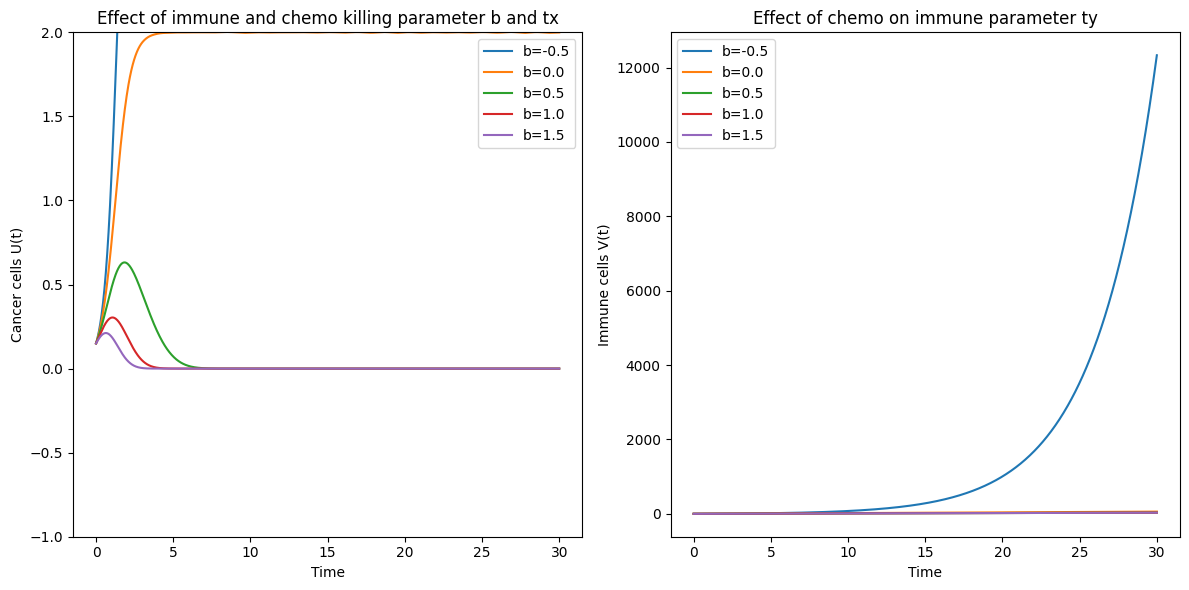

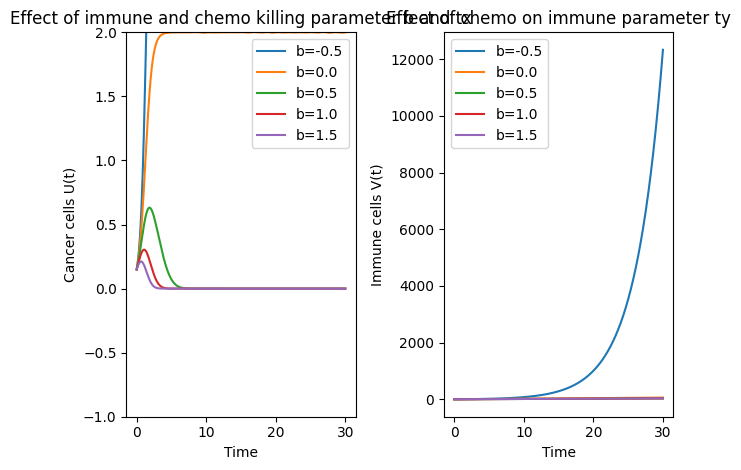

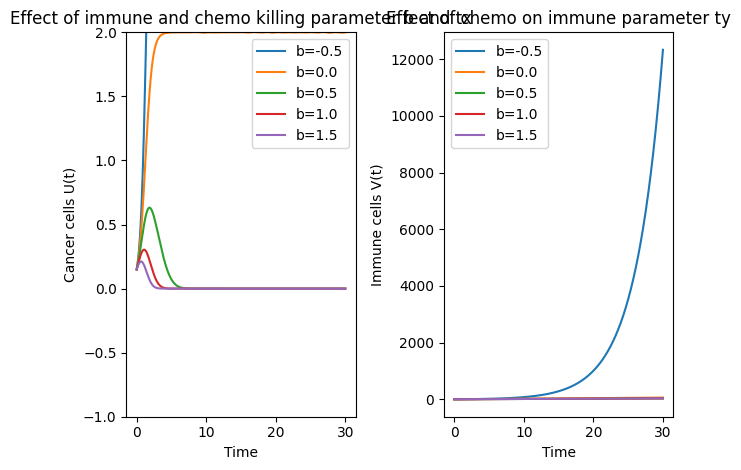

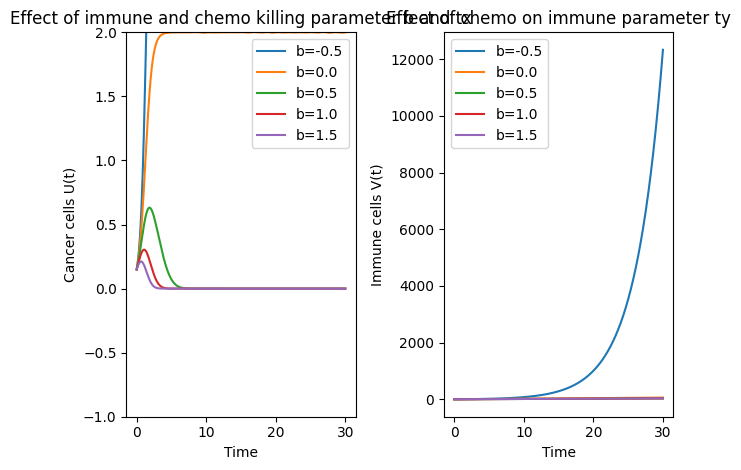

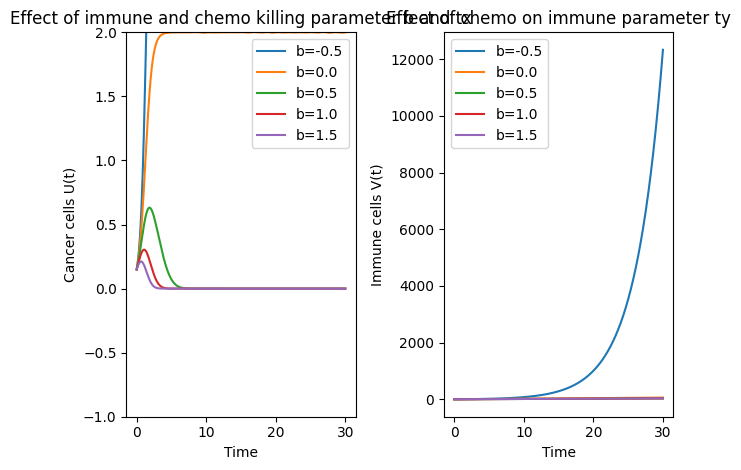

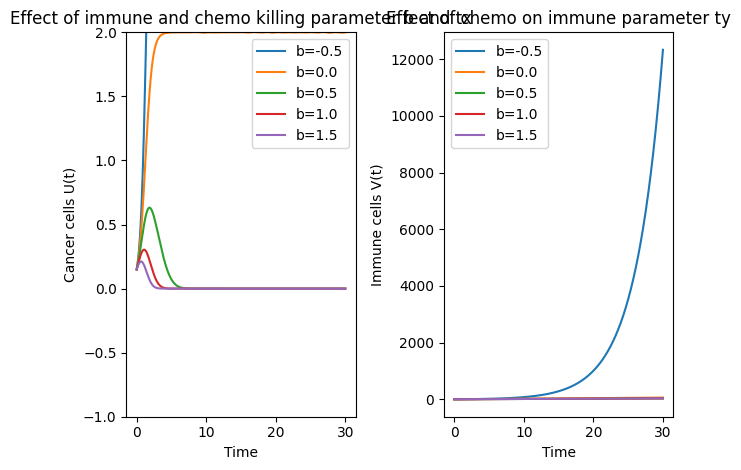

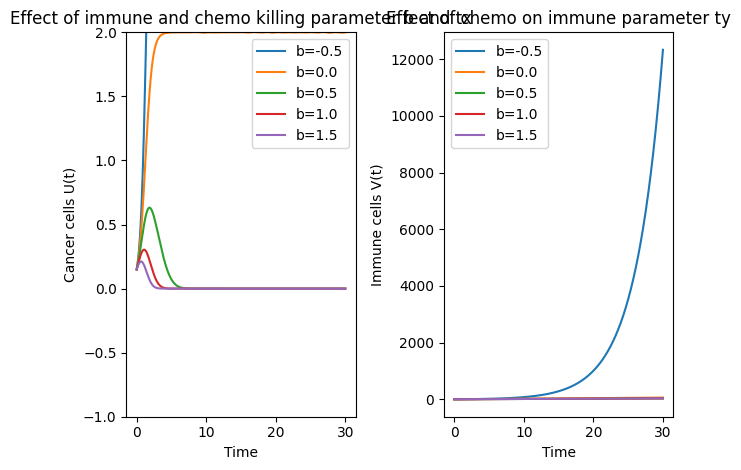

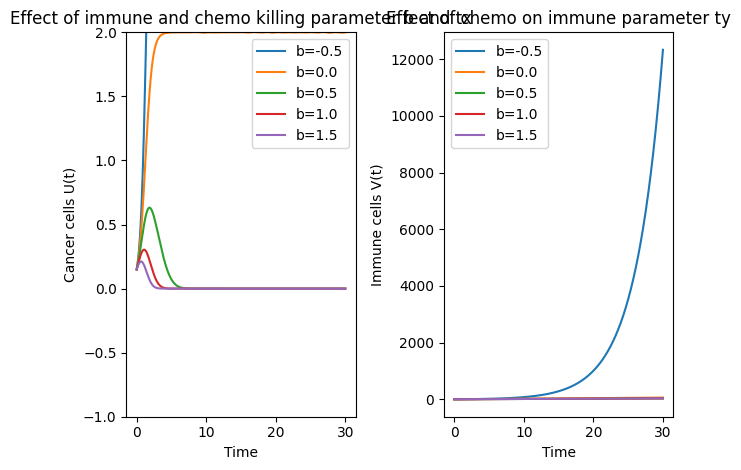

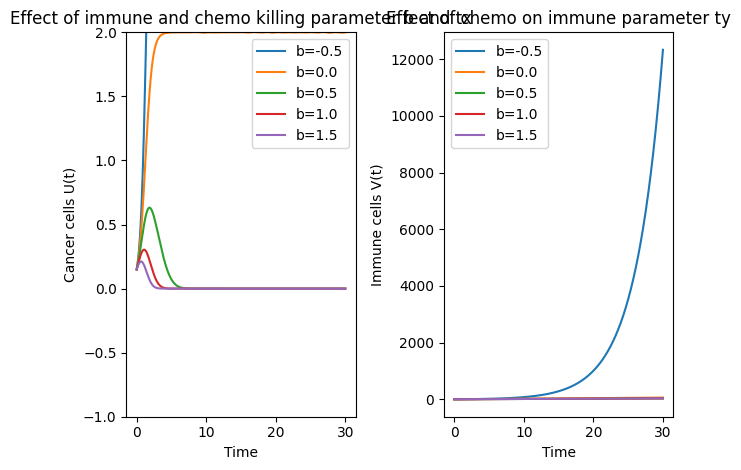

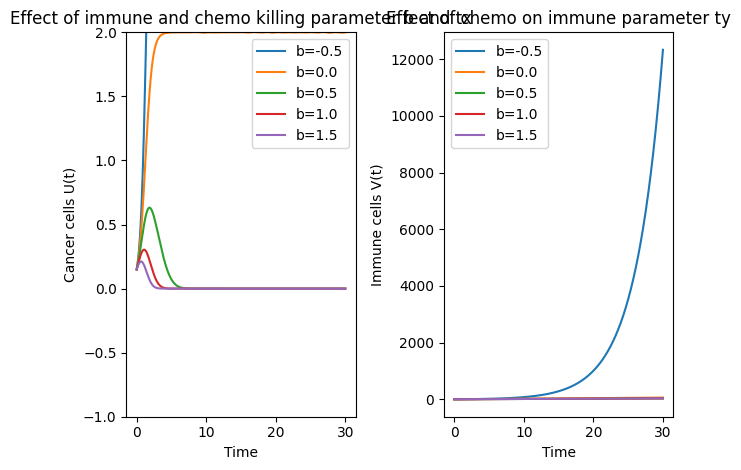

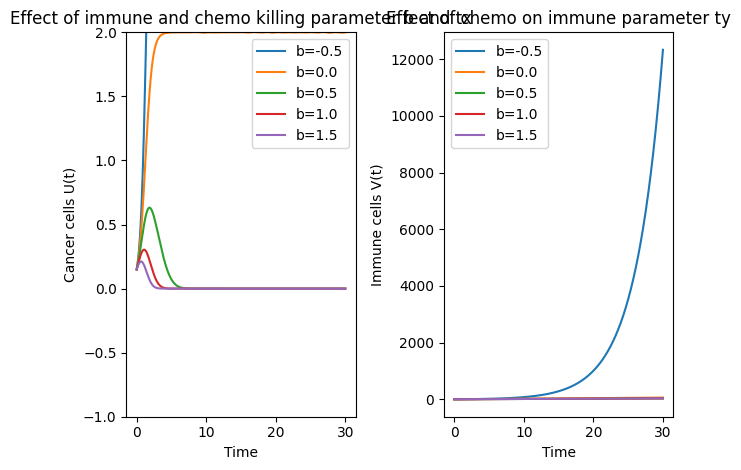

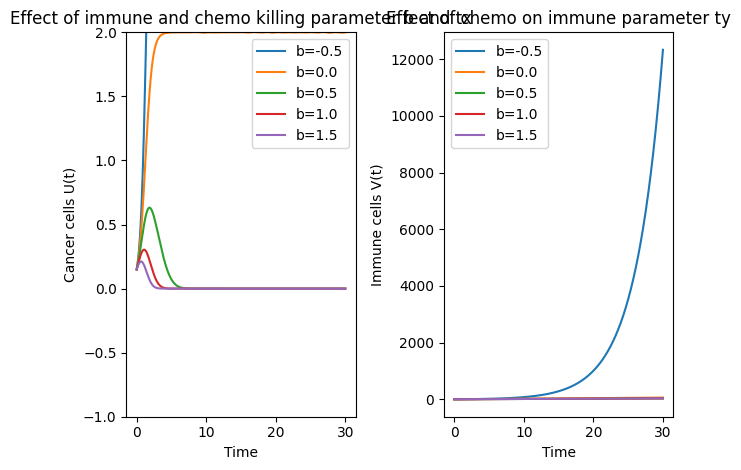

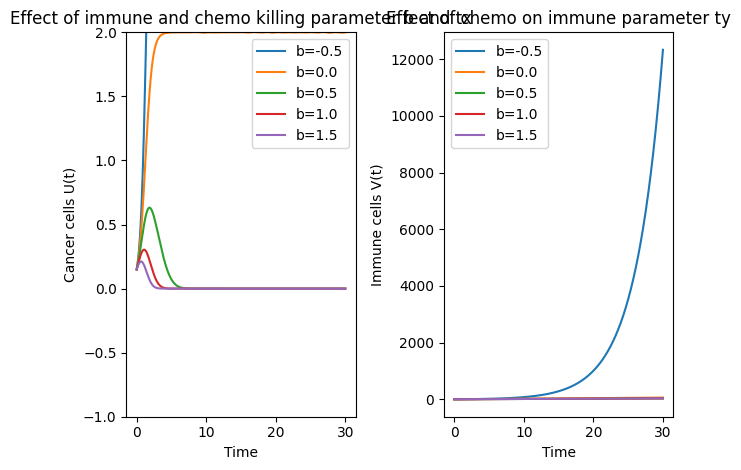

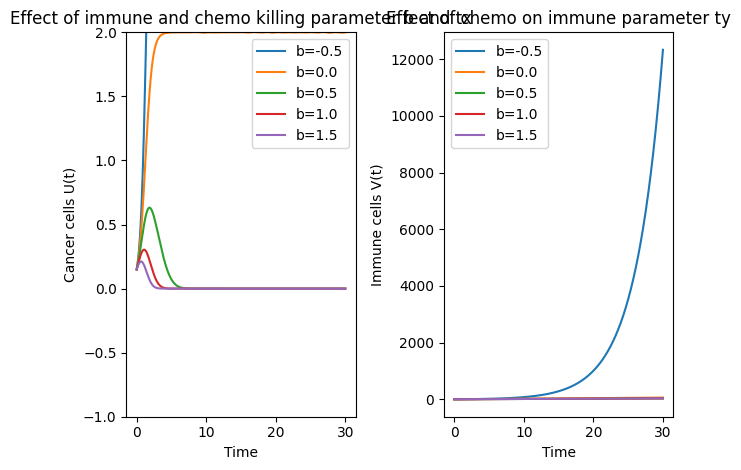

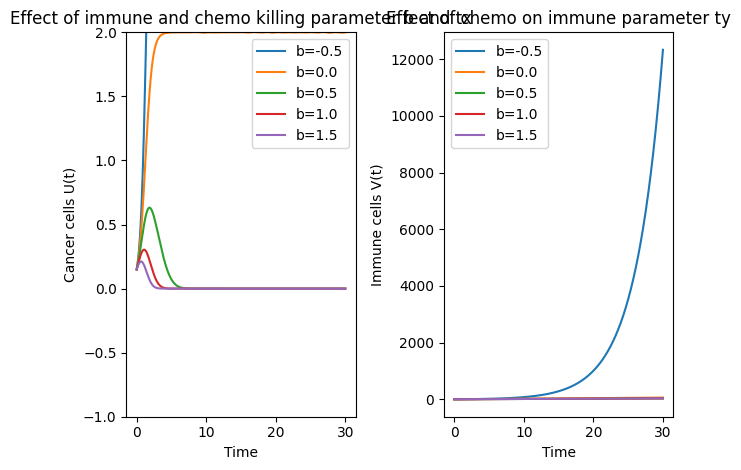

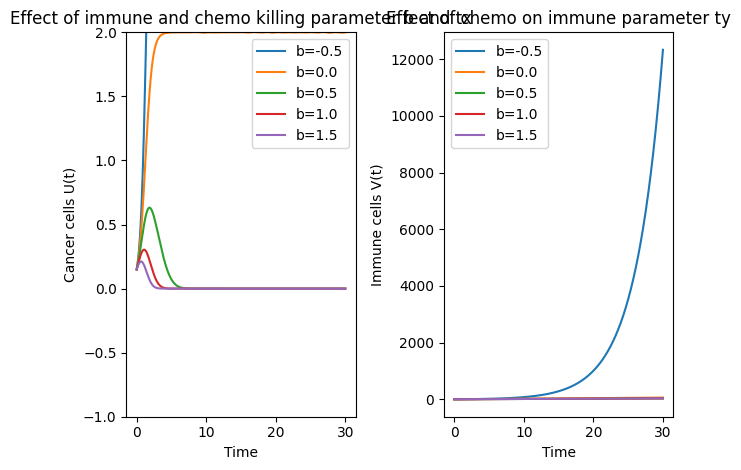

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def simulate_system(a, b, c, U0, V0, T, tx = 0.0, ty = 0.0):

    def system(t, y):
        U, V = y
        dU_dt = U * (1 - U) - b * V * U - tx * U
        dV_dt = c + a * U - c * V - ty * V
        return [dU_dt, dV_dt]

    t_span = (0, T)
    t_eval = np.linspace(0, T, 1000)
    y0 = [U0, V0]

    sol = solve_ivp(system, t_span, y0, t_eval=t_eval)

    U = sol.y[0]
    V = sol.y[1]
    t = sol.t

    return t, U, V


# Parameters
a = 0.5
c = 1.0
T = 30
U0 = 0.15
V0 = 0.5
tx = [-1,0,1,2]
ty = [-1,0,1,2]

b_values = [-0.5, 0.0, 0.5, 1.0, 1.5]

plt.figure(figsize=(12, 6))

U1 = []
V1 = []
T1 = []

for t1 in tx:
    for t2 in ty:
        for b in b_values:
            t, u, v = simulate_system(a, b, c, U0, V0, T, tx=t1, ty=t2)
            U1.append(u)
            V1.append(v)
            T1.append(t)

        plt.subplot(1, 2, 1)
        for b in range(len(b_values)):
            plt.plot(T1[b], U1[b], label=f'b={b_values[b]}')
        plt.xlabel("Time")
        plt.ylabel("Cancer cells U(t)")
        plt.ylim((-1,2))
        plt.legend()
        plt.title("Effect of immune and chemo killing parameter b and tx")

        plt.subplot(1, 2, 2)
        for b in range(len(b_values)):
            plt.plot(T1[b], V1[b], label=f'b={b_values[b]}')
        plt.xlabel("Time")
        plt.ylabel("Immune cells V(t)")
        plt.legend()
        plt.title("Effect of chemo on immune parameter ty")

        plt.tight_layout()
        plt.show()

